<a href="https://colab.research.google.com/github/ham-codes7/Exploratory-Data-Analysis-/blob/main/Exp_11_06_10_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

# Upload only if the files aren't already here
if not (os.path.exists("mnist_train.csv") and os.path.exists("mnist_test.csv")):
    from google.colab import files
    print("Select BOTH mnist_train.csv and mnist_test.csv from your Downloads folder")
    files.upload()

def load_mnist_csv(path):
    df = pd.read_csv(path, header=None)
    if not str(df.iloc[0, 0]).strip().isdigit():   # drop header row if present
        df = df.iloc[1:].reset_index(drop=True)
    df = df.astype(np.uint8)
    y = df.iloc[:, 0].values                        # first column = label
    X = df.iloc[:, 1:].values.reshape(-1, 28, 28)   # 784 pixel columns -> 28x28
    return X, y

X_train_img, y_train = load_mnist_csv("mnist_train.csv")
X_test_img,  y_test  = load_mnist_csv("mnist_test.csv")

print("Data loaded!")
print(f"Train: {X_train_img.shape}, Test: {X_test_img.shape}")

/tmp/ipykernel_1994/827374609.py:21: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,26

Data loaded!
Train: (3259, 28, 28), Test: (703, 28, 28)


Training samples : 3259
Test samples     : 703
Total samples    : 3962
Number of classes: 10
Image dimensions : 28 x 28 = 784 pixel features
Pixel value range: 0 to 255
--------------------------------------------------
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Number of samples per label
0: 309
1: 363
2: 326
3: 318
4: 357
5: 292
6: 328
7: 356
8: 294
9: 316


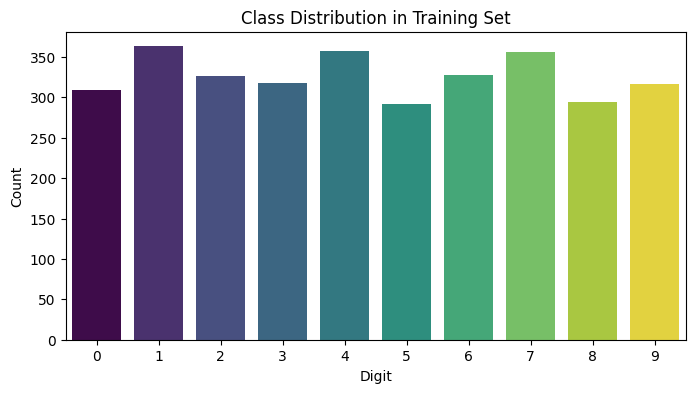

In [8]:
print(f"Training samples : {X_train_img.shape[0]}")
print(f"Test samples     : {X_test_img.shape[0]}")
print(f"Total samples    : {X_train_img.shape[0] + X_test_img.shape[0]}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Image dimensions : {X_train_img.shape[1]} x {X_train_img.shape[2]} "
      f"= {X_train_img.shape[1] * X_train_img.shape[2]} pixel features")
print(f"Pixel value range: {X_train_img.min()} to {X_train_img.max()}")

print("-" * 50)
unique_labels, label_count = np.unique(y_train, return_counts=True)
print(f"Unique labels: {unique_labels}")
print("Number of samples per label")
for lc in zip(unique_labels, label_count):
    print(f"{lc[0]}: {lc[1]}")

plt.figure(figsize=(8, 4))
sns.barplot(x=unique_labels, y=label_count, hue=unique_labels,
            palette="viridis", legend=False)
plt.title("Class Distribution in Training Set")
plt.xlabel("Digit"); plt.ylabel("Count")
plt.show()

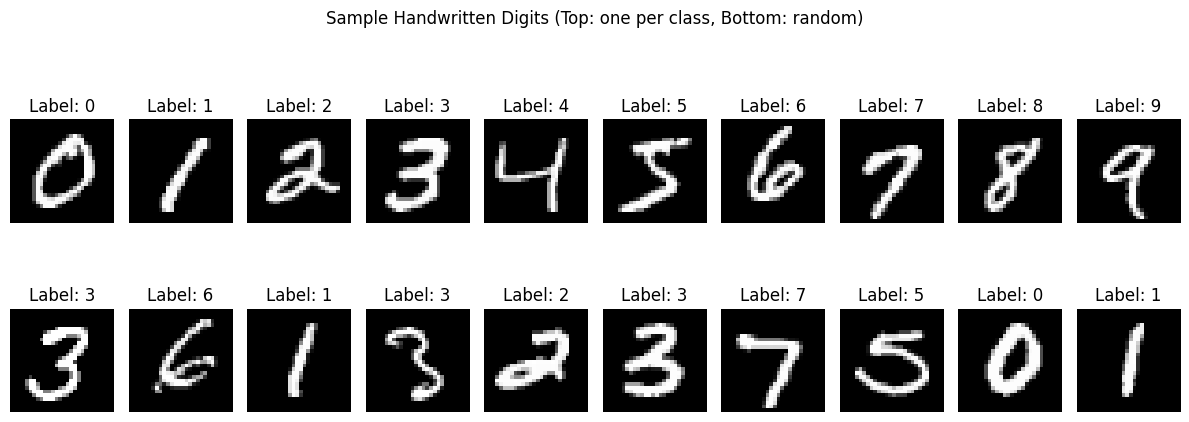

In [9]:
plt.figure(figsize=(12, 5))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    plt.subplot(2, 10, digit + 1)
    plt.imshow(X_train_img[idx], cmap="gray")
    plt.title(f"Label: {digit}")
    plt.axis("off")

rng = np.random.default_rng(42)
random_idx = rng.choice(len(X_train_img), 10, replace=False)
for i, idx in enumerate(random_idx):
    plt.subplot(2, 10, i + 11)
    plt.imshow(X_train_img[idx], cmap="gray")
    plt.title(f"Label: {y_train[idx]}")
    plt.axis("off")

plt.suptitle("Sample Handwritten Digits (Top: one per class, Bottom: random)")
plt.tight_layout()
plt.show()

In [10]:
X_train = X_train_img.reshape(-1, 784).astype("float32") / 255.0
X_test  = X_test_img.reshape(-1, 784).astype("float32") / 255.0

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"After normalization -> min: {X_train.min()}, max: {X_train.max()}")

X_train shape: (3259, 784), X_test shape: (703, 784)
After normalization -> min: 0.0, max: 1.0


In [11]:
pca_all = PCA()
pca_all.fit(X_train)

evr = pca_all.explained_variance_ratio_
cumsum = np.cumsum(evr)

var_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(20)],
    "Explained Variance (%)": np.round(evr[:20] * 100, 3),
    "Cumulative (%)": np.round(cumsum[:20] * 100, 3)
})
print(var_df.to_string(index=False))

print("-" * 50)
n_components = {}
for t in [0.90, 0.95, 0.99]:
    n = np.argmax(cumsum >= t) + 1
    n_components[t] = n
    print(f"Components needed for {int(t*100)}% variance: {n}")

  PC  Explained Variance (%)  Cumulative (%)
 PC1                   9.818        9.818000
 PC2                   7.330       17.149000
 PC3                   6.443       23.591999
 PC4                   5.423       29.014999
 PC5                   4.786       33.800999
 PC6                   4.484       38.285000
 PC7                   3.356       41.640999
 PC8                   2.957       44.598999
 PC9                   2.837       47.435001
PC10                   2.304       49.738998
PC11                   2.139       51.877998
PC12                   2.006       53.883999
PC13                   1.700       55.584000
PC14                   1.675       57.258999
PC15                   1.644       58.903000
PC16                   1.524       60.425999
PC17                   1.281       61.707001
PC18                   1.225       62.931999
PC19                   1.169       64.100998
PC20                   1.150       65.251999
--------------------------------------------------
Comp

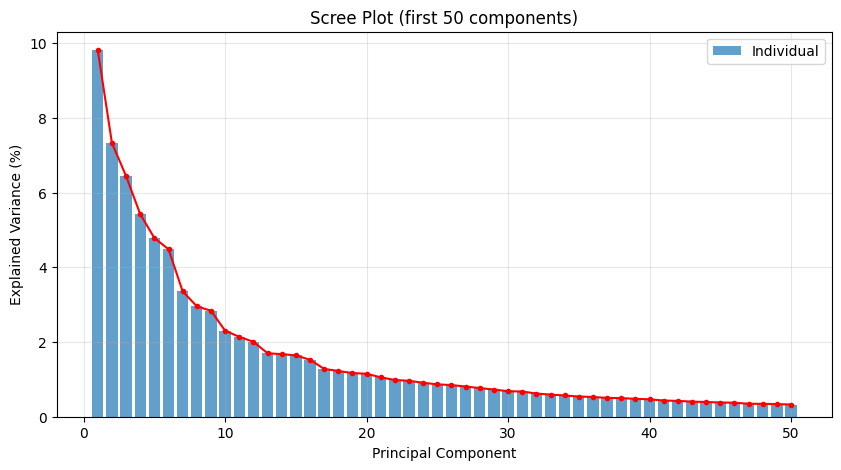

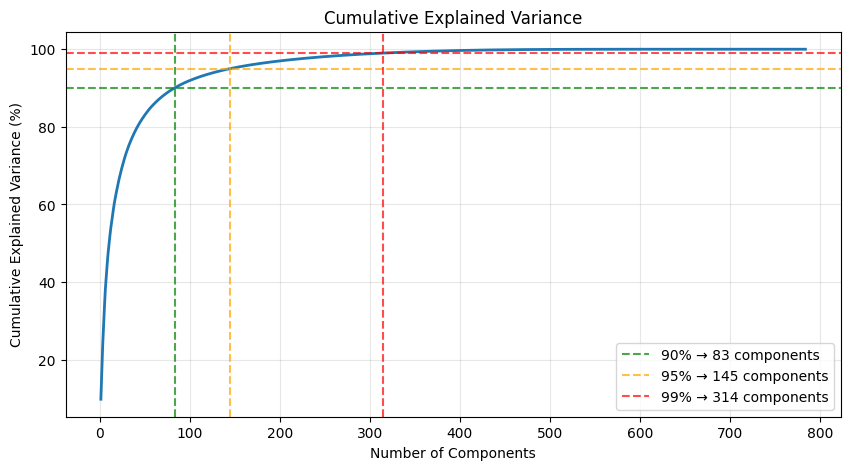

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, 51), evr[:50] * 100, alpha=0.7, label="Individual")
plt.plot(range(1, 51), evr[:50] * 100, "ro-", markersize=3)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot (first 50 components)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumsum) + 1), cumsum * 100, linewidth=2)
colors = {0.90: "green", 0.95: "orange", 0.99: "red"}
for t, n in n_components.items():
    plt.axhline(t * 100, color=colors[t], linestyle="--", alpha=0.7)
    plt.axvline(n, color=colors[t], linestyle="--", alpha=0.7,
                label=f"{int(t*100)}% → {n} components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

2D PCA shape: (3259, 2), variance retained: 17.15%
50D PCA shape: (3259, 50), variance retained: 83.09%


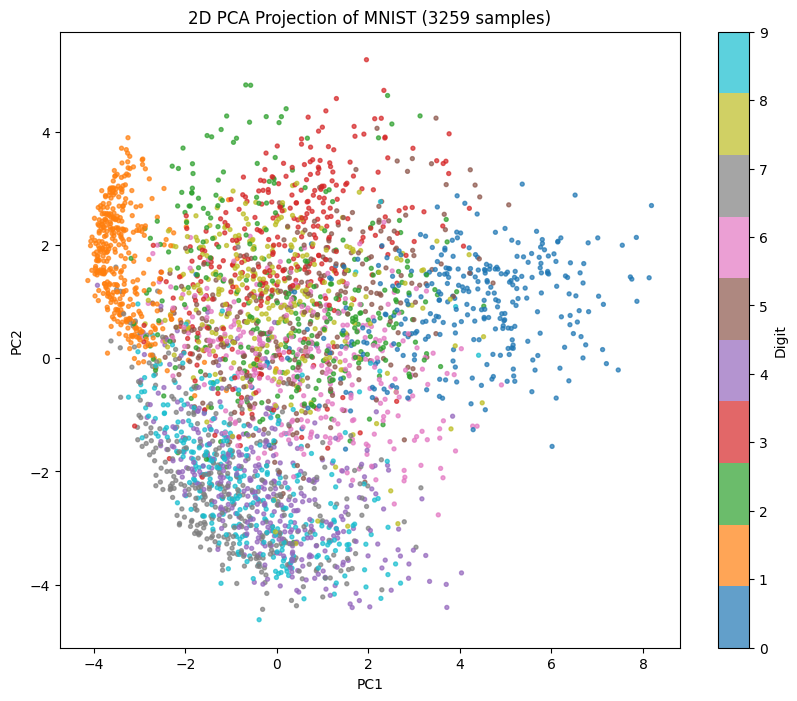

In [16]:
pca_2 = PCA(n_components=2)
X_train_pca2 = pca_2.fit_transform(X_train)
X_test_pca2  = pca_2.transform(X_test)
print(f"2D PCA shape: {X_train_pca2.shape}, "
      f"variance retained: {pca_2.explained_variance_ratio_.sum()*100:.2f}%")

pca_50 = PCA(n_components=50)
X_train_pca = pca_50.fit_transform(X_train)
X_test_pca  = pca_50.transform(X_test)
print(f"50D PCA shape: {X_train_pca.shape}, "
      f"variance retained: {pca_50.explained_variance_ratio_.sum()*100:.2f}%")

plt.figure(figsize=(10, 8))
sc = plt.scatter(X_train_pca2[:, 0], X_train_pca2[:, 1],
                 c=y_train, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(sc, ticks=range(10), label="Digit")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"2D PCA Projection of MNIST ({len(X_train_pca2)} samples)")
plt.show()

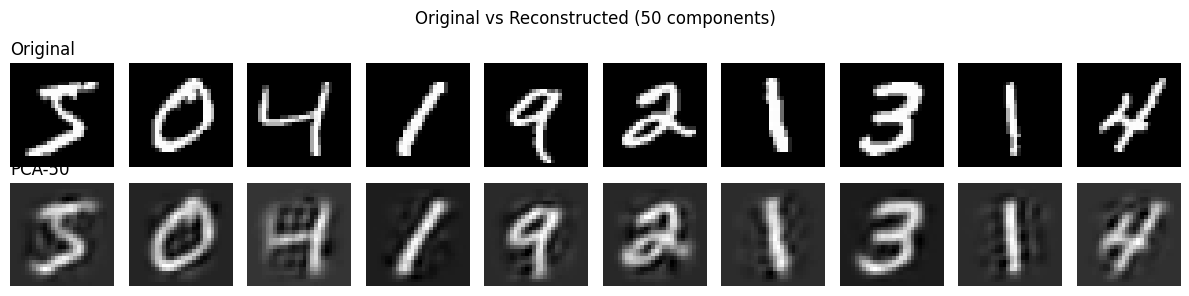

In [17]:
X_train_pca_recon = pca_50.inverse_transform(X_train_pca)

plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0: plt.title("Original", loc="left")
    plt.subplot(2, 10, i + 11)
    plt.imshow(X_train_pca_recon[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0: plt.title("PCA-50", loc="left")
plt.suptitle("Original vs Reconstructed (50 components)")
plt.tight_layout()
plt.show()

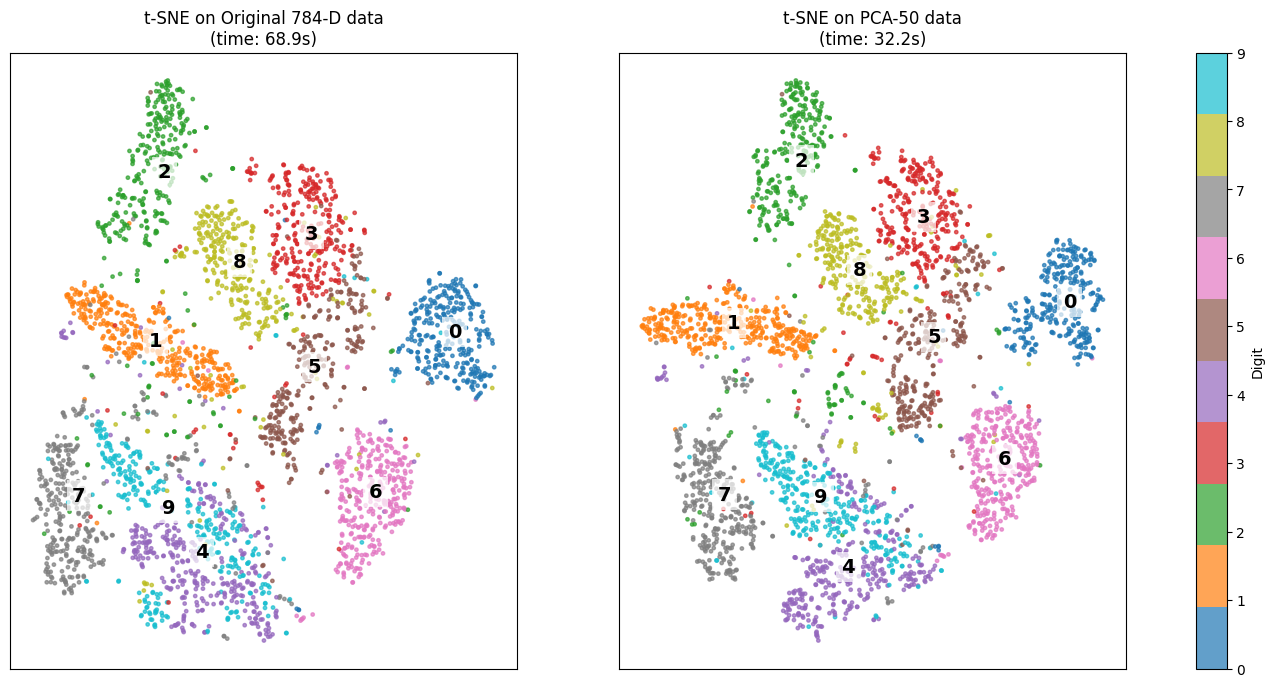

t-SNE time on original (784-D): 68.89 s
t-SNE time on PCA (50-D)      : 32.24 s


In [18]:
X_sub, X_sub_pca, y_sub = X_train, X_train_pca, y_train

def plot_embedding(emb, labels, title, ax):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap="tab10", s=6, alpha=0.7)
    for d in range(10):
        cx, cy = np.median(emb[labels == d], axis=0)
        ax.text(cx, cy, str(d), fontsize=14, weight="bold",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    return sc

t0 = time.time()
emb_orig = TSNE(n_components=2, perplexity=30, init="pca",
                random_state=42).fit_transform(X_sub)
time_orig = time.time() - t0

t0 = time.time()
emb_pca = TSNE(n_components=2, perplexity=30, init="pca",
               random_state=42).fit_transform(X_sub_pca)
time_pca = time.time() - t0

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plot_embedding(emb_orig, y_sub, f"t-SNE on Original 784-D data\n(time: {time_orig:.1f}s)", axes[0])
sc = plot_embedding(emb_pca, y_sub, f"t-SNE on PCA-50 data\n(time: {time_pca:.1f}s)", axes[1])
fig.colorbar(sc, ax=axes, ticks=range(10), label="Digit")
plt.show()

print(f"t-SNE time on original (784-D): {time_orig:.2f} s")
print(f"t-SNE time on PCA (50-D)      : {time_pca:.2f} s")

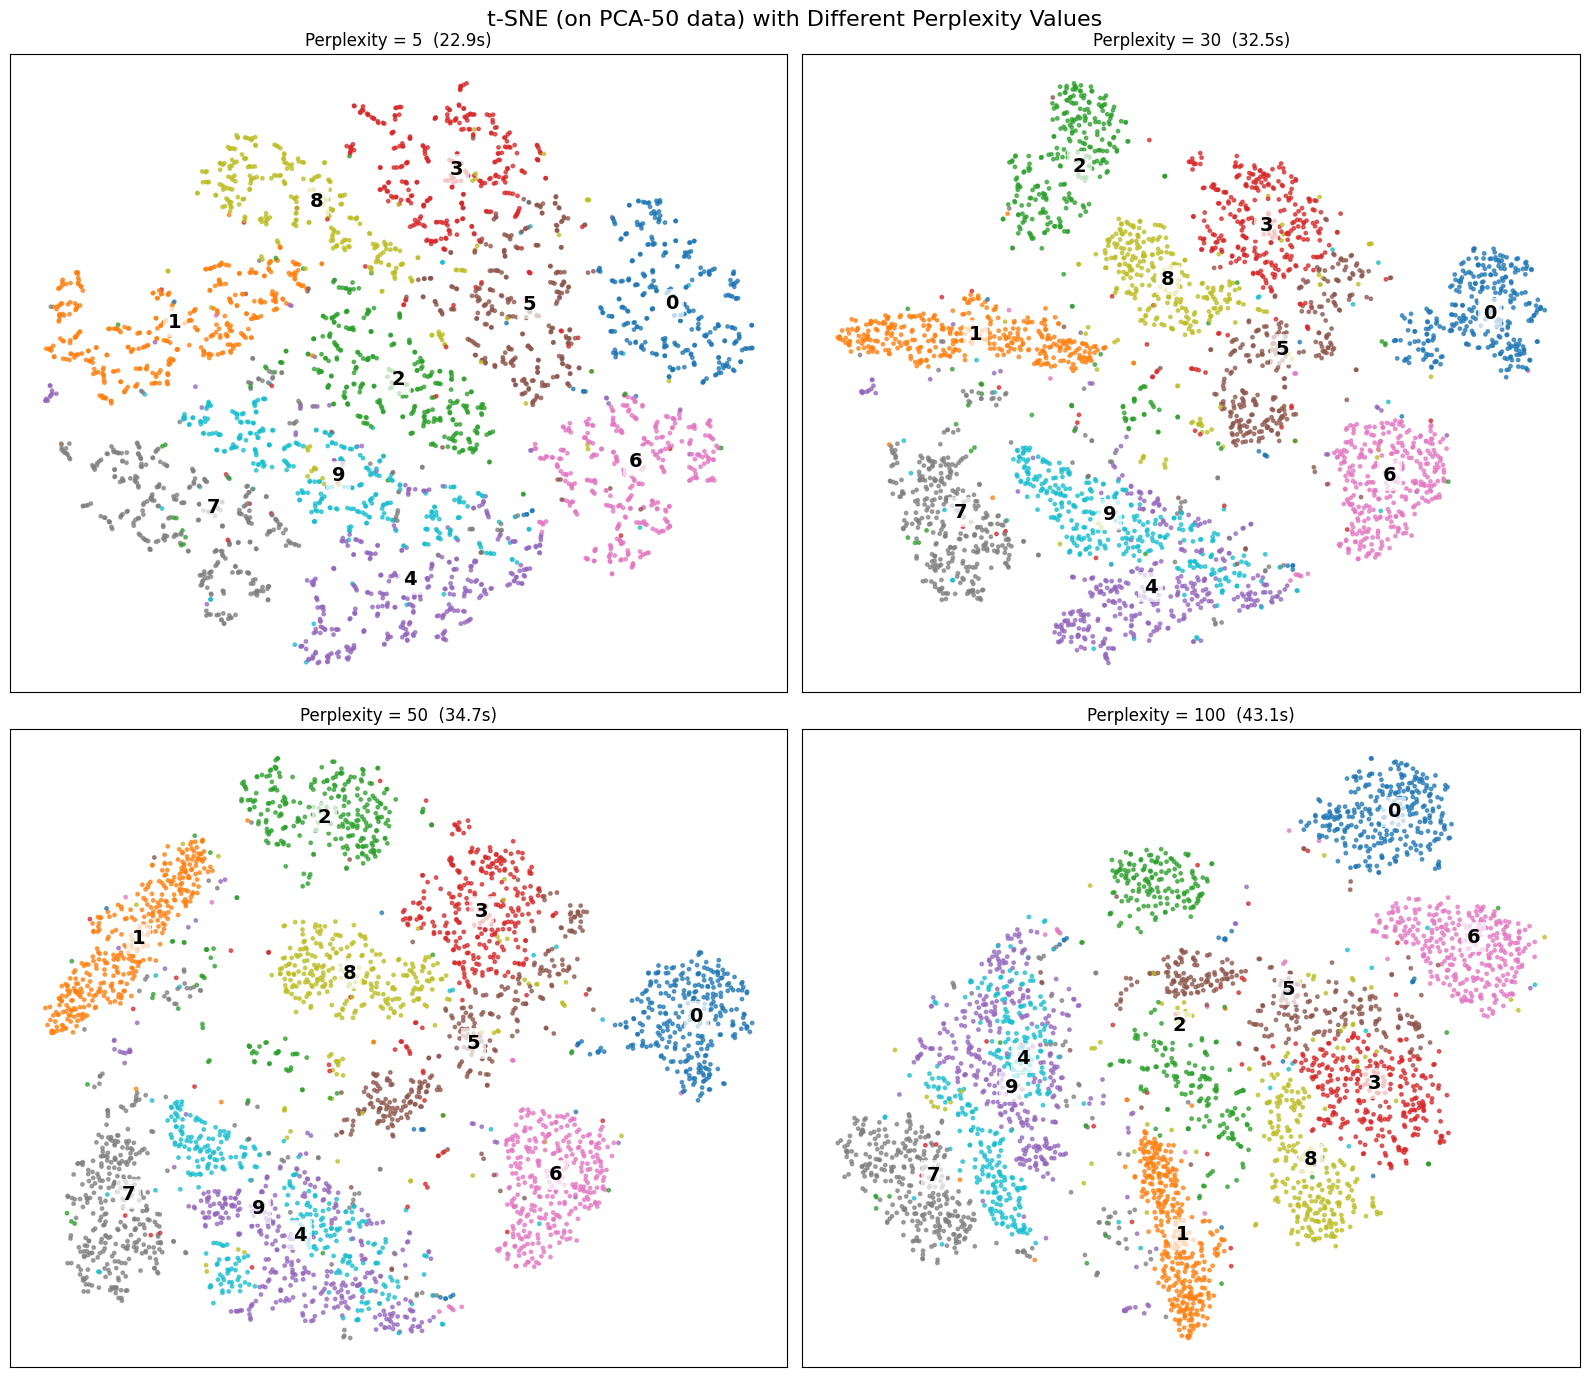

In [19]:
perplexities = [5, 30, 50, 100]
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, p in zip(axes.ravel(), perplexities):
    t0 = time.time()
    emb = TSNE(n_components=2, perplexity=p, init="pca",
               random_state=42).fit_transform(X_sub_pca)
    plot_embedding(emb, y_sub, f"Perplexity = {p}  ({time.time()-t0:.1f}s)", ax)
plt.suptitle("t-SNE (on PCA-50 data) with Different Perplexity Values", fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
results = []

def evaluate_knn(name, Xtr, Xte):
    print(f"Training and evaluating KNN with {name} data ({Xtr.shape[1]} dims)...")
    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    t0 = time.time(); knn.fit(Xtr, y_train); train_t = time.time() - t0
    t0 = time.time(); y_pred = knn.predict(Xte); pred_t = time.time() - t0
    acc = accuracy_score(y_test, y_pred)
    results.append({"Data": name, "Dimensions": Xtr.shape[1],
                    "Accuracy (%)": round(acc * 100, 2),
                    "Training Time (s)": round(train_t, 4),
                    "Prediction Time (s)": round(pred_t, 4),
                    "Memory (MB)": round(Xtr.nbytes / 1024**2, 2)})
    print(f"  Accuracy: {acc*100:.2f}% | Train: {train_t:.4f}s | Predict: {pred_t:.4f}s")
    print("-" * 50)
    return y_pred

y_pred_original = evaluate_knn("Original", X_train, X_test)
y_pred_pca2     = evaluate_knn("PCA-2", X_train_pca2, X_test_pca2)
y_pred_pca      = evaluate_knn("PCA-50", X_train_pca, X_test_pca)

pca_95 = PCA(n_components=0.95)
X_train_pca95 = pca_95.fit_transform(X_train)
X_test_pca95  = pca_95.transform(X_test)
y_pred_pca95  = evaluate_knn(f"PCA-95% ({pca_95.n_components_}D)", X_train_pca95, X_test_pca95)

lda = LinearDiscriminantAnalysis(n_components=9)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda  = lda.transform(X_test)
y_pred_lda  = evaluate_knn("LDA", X_train_lda, X_test_lda)

results_df = pd.DataFrame(results)
print("\nPerformance Results:")
print(results_df.to_string(index=False))

Training and evaluating KNN with Original data (784 dims)...
  Accuracy: 88.62% | Train: 0.0195s | Predict: 0.1730s
--------------------------------------------------
Training and evaluating KNN with PCA-2 data (2 dims)...
  Accuracy: 39.12% | Train: 0.0038s | Predict: 0.0173s
--------------------------------------------------
Training and evaluating KNN with PCA-50 data (50 dims)...
  Accuracy: 91.32% | Train: 0.0016s | Predict: 0.0190s
--------------------------------------------------
Training and evaluating KNN with PCA-95% (145D) data (145 dims)...
  Accuracy: 89.33% | Train: 0.0060s | Predict: 0.0795s
--------------------------------------------------
Training and evaluating KNN with LDA data (9 dims)...
  Accuracy: 80.65% | Train: 0.0061s | Predict: 0.0486s
--------------------------------------------------

Performance Results:
          Data  Dimensions  Accuracy (%)  Training Time (s)  Prediction Time (s)  Memory (MB)
      Original         784         88.62             0.019

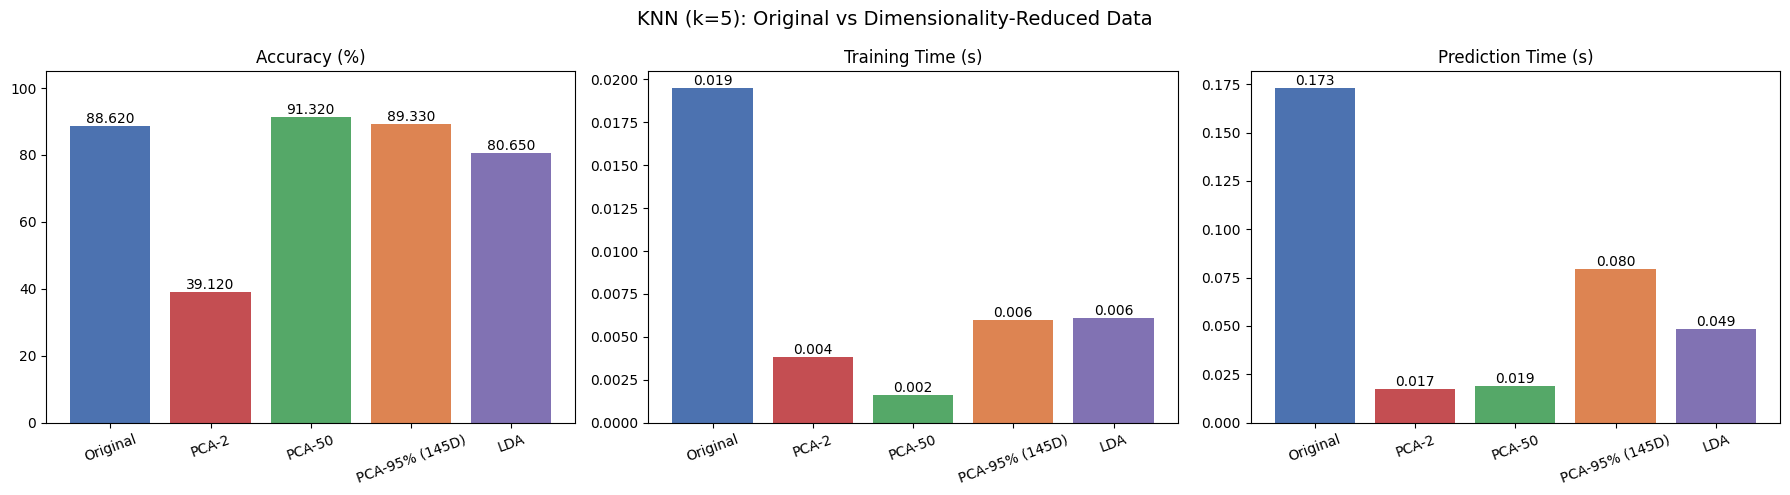

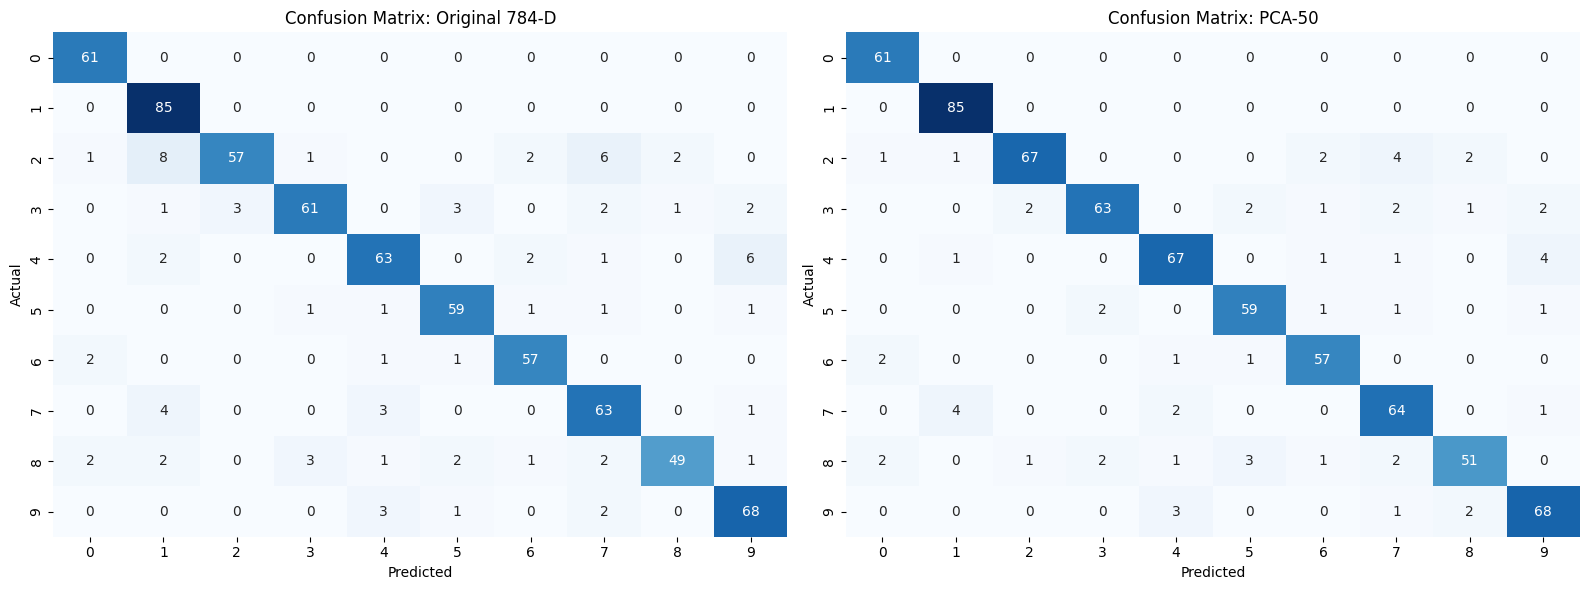

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["Accuracy (%)", "Training Time (s)", "Prediction Time (s)"]
palette = ["#4C72B0", "#C44E52", "#55A868", "#DD8452", "#8172B3"]
for ax, m in zip(axes, metrics):
    bars = ax.bar(results_df["Data"], results_df[m], color=palette)
    ax.set_title(m); ax.tick_params(axis="x", rotation=20)
    ax.bar_label(bars, fmt="%.3f")
axes[0].set_ylim(0, 105)
plt.suptitle("KNN (k=5): Original vs Dimensionality-Reduced Data", fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (pred, title) in zip(axes, [(y_pred_original, "Original 784-D"),
                                    (y_pred_pca, "PCA-50")]):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d",
                cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"Confusion Matrix: {title}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()